# **Initializations and Dataset Download**

In [84]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


# Import Library

In [85]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torchvision import models # import pretrained models in PyTorch library
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects

In [86]:
from PIL import Image # Used to read the images from the directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import os


In [87]:
# detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Reading Data

In [88]:
train_df=pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
val_df=pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")

In [89]:
train_df['image:FILE']="/content/bean-leaf-lesions-classification/"+ train_df['image:FILE']
val_df['image:FILE']="/content/bean-leaf-lesions-classification/"+  val_df['image:FILE']

In [90]:
train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [91]:
val_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/val/...,0
1,/content/bean-leaf-lesions-classification/val/...,0
2,/content/bean-leaf-lesions-classification/val/...,0
3,/content/bean-leaf-lesions-classification/val/...,0
4,/content/bean-leaf-lesions-classification/val/...,0


In [92]:
train_df['category'].unique()

array([0, 1, 2])

In [93]:
print(train_df.shape)
print(val_df.shape)

(1034, 2)
(133, 2)


In [94]:
print(train_df['category'].value_counts())


category
2    348
1    345
0    341
Name: count, dtype: int64


In [95]:
print(val_df['category'].value_counts())

category
2    45
0    44
1    44
Name: count, dtype: int64


# Preprocessing Objects

In [96]:
transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float32)
])


# Custom Dataset Class

In [97]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe=dataframe
    self.transform=transform
    self.labels=torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self,idx):
    image_path=self.dataframe.iloc[idx,0]
    label = self.labels[idx]
    image=Image.open(image_path)
    if self.transform:
      image=(self.transform(image)/255.0).to(device)

    return image,label



# Create Dataset Objects

In [98]:
train_dataset=CustomImageDataset(dataframe=train_df,transform=transform)
val_dataset=CustomImageDataset(dataframe=val_df,transform=transform)

# Visualize Images

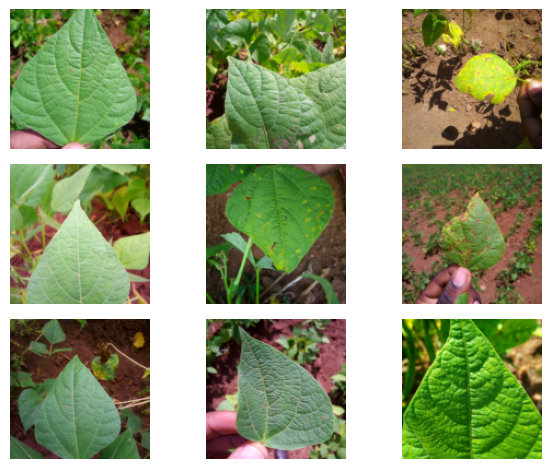

In [101]:
n_rows = 3
n_cols = 3
f, axarr = plt.subplots(n_rows, n_cols)
for row in range(n_rows):
    for col in range(n_cols):
        image = train_dataset[np.random.randint(0,train_dataset.__len__())][0].cpu()
        axarr[row, col].imshow((image*255).squeeze().permute(1,2,0))
        axarr[row, col].axis('off')

plt.tight_layout()
plt.show()

# Hyperparameters

In [122]:
LR = 1e-3
BATCH_SIZE = 4
EPOCHS = 25

In [104]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [105]:
googlenet_model=models.googlenet(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 179MB/s]


# **Transfer Learning**

In [107]:
for param in googlenet_model.parameters():
  param.requires_grad=True

In [108]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [111]:
num_classes = len(train_df["category"].unique())
num_classes

3

In [116]:
googlenet_model.fc=torch.nn.Linear(googlenet_model.fc.in_features,out_features=num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [117]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [120]:
# Define loss function and optimizer

criterion = nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)

# Train the Model

In [123]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for (inputs, labels) in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}%')

Epoch 1/25, Train Loss: 1.0019 Train Accuracy 87.1373%
Epoch 2/25, Train Loss: 0.6564 Train Accuracy 91.0058%
Epoch 3/25, Train Loss: 0.8115 Train Accuracy 88.4913%
Epoch 4/25, Train Loss: 0.6711 Train Accuracy 90.1354%
Epoch 5/25, Train Loss: 0.6349 Train Accuracy 90.9091%
Epoch 6/25, Train Loss: 0.7386 Train Accuracy 88.9749%
Epoch 7/25, Train Loss: 0.6813 Train Accuracy 90.2321%
Epoch 8/25, Train Loss: 0.6375 Train Accuracy 91.3926%
Epoch 9/25, Train Loss: 0.6319 Train Accuracy 91.1992%
Epoch 10/25, Train Loss: 0.6528 Train Accuracy 90.2321%
Epoch 11/25, Train Loss: 0.3866 Train Accuracy 94.4874%
Epoch 12/25, Train Loss: 0.5292 Train Accuracy 91.3926%
Epoch 13/25, Train Loss: 0.5095 Train Accuracy 92.94%
Epoch 14/25, Train Loss: 0.5176 Train Accuracy 92.8433%
Epoch 15/25, Train Loss: 0.4215 Train Accuracy 93.8104%
Epoch 16/25, Train Loss: 0.3204 Train Accuracy 95.8414%
Epoch 17/25, Train Loss: 0.3774 Train Accuracy 95.3578%
Epoch 18/25, Train Loss: 0.2852 Train Accuracy 96.6151%
Epo

In [124]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for indx, (input, labels) in enumerate(test_loader):

    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc


In [125]:
print(f"Accuracy Score is: {round((total_acc_test/val_dataset.__len__())*100, 2)}%")

Accuracy Score is: 90.23%


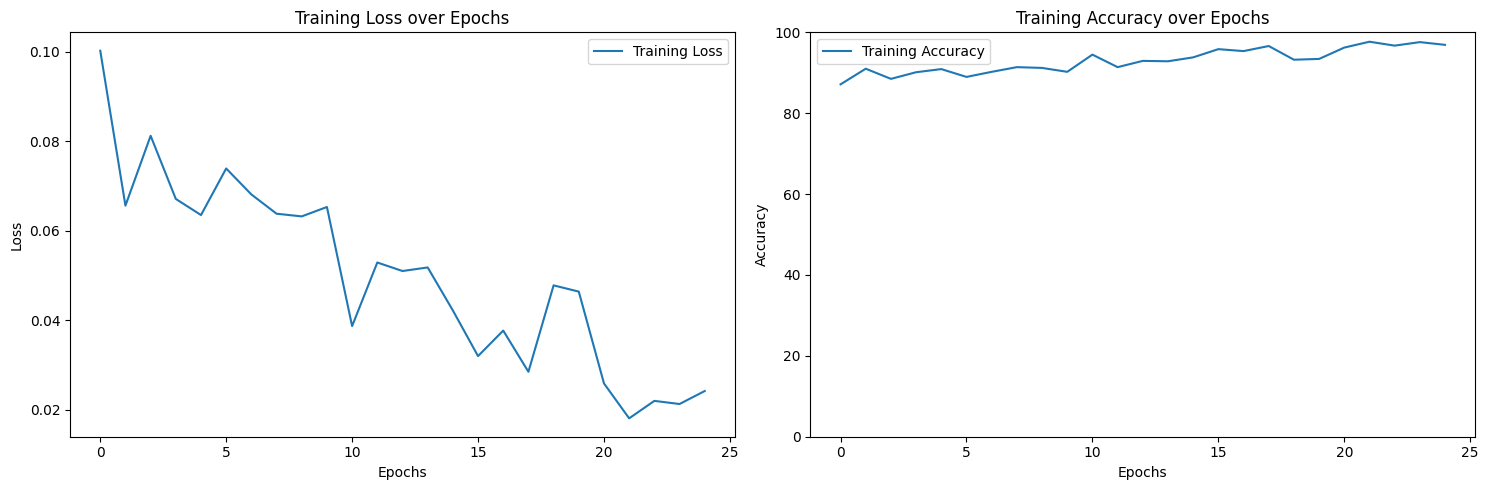

In [126]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].set_title('Training Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].set_title('Training Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()